In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Лабораторная работа №3

Написали: Кривенцова Юля [408902] и Латышева Анастасия [408987]

#Задача Коши

Требуется исследовать поведение численного решения при разных шагах для уравнения
$$x^2 y'' - x(x^2 - 1)y' - (x^2 + 1)y = 0,$$
при начальных условиях
$$y(1) = 1 + e^{1/2}, \qquad y'(1) = - 1,$$
на отрезке
$
x \in [1,2].
$

Для получения численного решения уравнение второго порядка сводится к системе из двух уравнений первого порядка:
$$
\begin{cases}
y_1' = y_2, \\[6pt]
y_2' = \left(x-\frac{1}{x}\right)y_2 + \left(1+\frac{1}{x^2}\right)y_1,
\end{cases}
\qquad
y_1(1)=1+e^{1/2},\ \ y_2(1)=-1.
$$

Решение задачи Коши: $y(x) = \frac{1}{x}(1+e^{x^2/2})$

In [ ]:
y_exact = lambda x: (1 + np.exp(x**2 / 2)) / x

## Явный метод Эйлера

В методе Эйлера уравнение заменяется разностным уравнением
\begin{equation}
\frac{y_{n+1}-y_n}{h} - f(x_n, y_n) = 0,
\qquad n = 0,1,2,\ldots,
\qquad y_0 = y(x_0).
\end{equation}

Решение уравнения находится явным образом по рекуррентной формуле
$$
y_{n+1} = y_n + h f(x_n, y_n),
\qquad n = 0,1,\ldots,
\qquad y_0 = y(x_0).
$$

В случае нашей системы:
$$y_{n+1} = y_n + h \begin{pmatrix}
0 & 1 \\
1 + \frac{1}{x^2_n} & x_n - \frac{1}{x_n}
\end{pmatrix}y_n, \quad
y_0=
\begin{pmatrix}
1+e^{1/2}\\
-1
\end{pmatrix}. $$

Или через систему
$$
\begin{cases}
y_{1,n+1} = y_{1,n} + h\,y_{2,n},\\[6pt]
y_{2,n+1} = y_{2,n}
+ h\left[
\left(x_n - \dfrac{1}{x_n}\right)y_{2,n}
+
\left(1 + \dfrac{1}{x^2_n}\right)y_{1,n}
\right],
\end{cases}
$$
где
$$y_0 =
\begin{pmatrix}
y_1(1)\\
y_2(1)
\end{pmatrix}
=
\begin{pmatrix}
1+e^{1/2}\\
-1
\end{pmatrix}.$$

In [ ]:
def f(x, y):
    y1, y2 = y
    return np.array([y2, (x - 1/x) * y2 + (1 + 1/x**2) * y1])

Функция ``euler_explicit(f, x0, y0, h, x_max)`` реализует явный метод Эйлера, принимая на вход начало ``x0`` и конец ``x_max`` рассматриваемого отрезка, функцию ``f`` и длину шага ``h``.

In [ ]:
def euler_explicit(f, x0, y0, h, x_max):
    x = np.arange(x0, x_max + h, h)

    y0_arr = np.array(y0, dtype=float)
    y = np.zeros((len(x),) + np.shape(y0), dtype=float)
    y[0] = y0_arr

    for n in range(len(x) - 1):
        y[n + 1] = y[n] + h * f(x[n], y[n])

    return x, y

Функция ``plot_solution(method, method_name, f, x0, y0, x_max, hs, y_exact_func)``
строит графики численного решения задачи Коши для ОДУ, полученные методом
``method``, при различных значениях шага ``h`` из ``hs``,
также для сравнения строит функцию точного решения
``y_exact_func`` на отрезке с началом ``x0`` и концом ``x_max``.



In [ ]:
def plot_solution(method, method_name, f, x0, y0, x_max, hs, y_exact_func):
    plt.figure(figsize=(7, 4))

    for h in hs:
        x, y = method(f, x0, y0, h, x_max)
        plt.plot(x, y[:, 0], marker='o', markersize=3, label=f"h = {h}")

    x_exact = np.linspace(x0, x_max, 500)
    y_exact = y_exact_func(x_exact)
    plt.plot(x_exact, y_exact, linewidth=2, color='black', label="exact solution")

    plt.xlabel("x")
    plt.ylabel("y(x)")
    plt.title(method_name)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

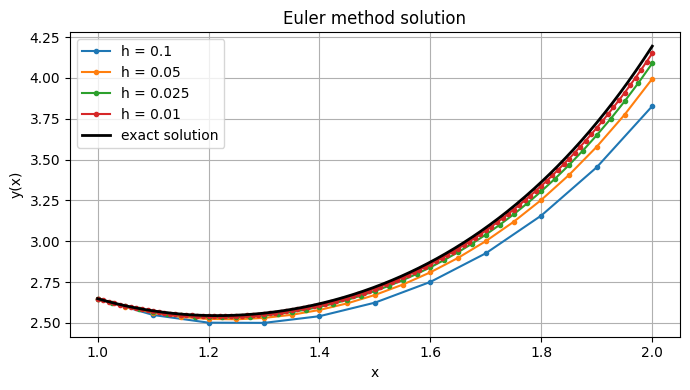

In [ ]:
x0 = 1.0
x_max = 2.0
y0 = np.array([1+np.exp(1/2), -1])
hs = [0.1, 0.05, 0.025, 0.01]

plot_solution(
    method=euler_explicit,
    method_name="Euler method solution",
    f=f,
    x0=x0,
    y0=y0,
    x_max=x_max,
    hs=hs,
    y_exact_func=y_exact)

Метод Эйлера относится к разностным методам. Применительно к ним используется понятие сходимости при $h \rightarrow 0$.

Метод сходится в точке $t$, если $|y_n-y(x_n)| \rightarrow 0$ при $h \rightarrow 0$ и $x_n = x$. Метод сходится на отрезке $[x_0, x_\textrm{max}]$, если он сходится в каждой точке $x \in [x_0, x_\textrm{max}]$.

Метод имеет $p$ порядок точности, если $$\exists p>0: |y_n-y(x_n)| = O(h^p), \quad h \rightarrow 0.$$

Если $z_n$ $-$ погрешность метода, то $y_n = z_n + y(x_n)$. Подставляя это в разностное уравнение, получается
$$
\frac{z_{n+1}-z_n}{h}
=
f(x_n, y_n + z_n)
-
\frac{y_{n+1}-y_n}{h}.
$$

Правая часть уравнения представляется в виде суммы
$
\psi^{(1)}_n + \psi^{(2)}_n,
$
где
$$
\psi^{(1)}_n
=
-\frac{y_{n+1}-y_n}{h}
+
f(x_n,y_n),
\qquad
\psi^{(2)}_n
=
f(x_n, y_n + z_n)
-
f(x_n, y_n).
$$

Функция $\psi^{(1)}_n$ называется невязкой или
погрешностью аппроксимации
разностного уравнения.

Разностный метод аппроксимирует исходное дифференциальное уравнение, если
$\psi_n^{(1)} \to 0$ при $h \to 0$. Разностный метод имеет $p$-й
порядок аппроксимации, если $\psi_n^{(1)} = O(h^p).$

Порядок аппроксимации метода Эйлера находится, используя
разложение по формуле Тейлора:
$$
\frac{y_{n+1}-y_n}{h}
= y'(x_n) + O(h),
$$
значит,
$$
\psi_n^{(1)} = -y'(x_n) + f(x_n, y_n) + O(h) = O(h),
$$

Метод Эйлера имеет первый порядок аппроксимации.

In [ ]:
def plot_errors_slopes(method, f, x0, y0, x_max, hs, x_stars, y_exact):
    hs = np.array(sorted(hs), dtype=float)
    logh = np.log(hs)

    plt.figure(figsize=(6, 4))

    for x_star in x_stars:
        err = []

        for h in hs:
            x, y = method(f, x0, y0, h, x_max)
            idx = np.argmin(np.abs(x - x_star))
            err.append(abs(y[idx, 0] - y_exact(x[idx])))

        err = np.array(err, dtype=float)
        slopes = np.diff(np.log(err)) / np.diff(logh)
        p = slopes.mean()

        print(f"x = {x_star}: p ≈ {p:.4f}")
        plt.loglog(hs, err, marker='o', label=fr"x = {x_star}, $p\approx{p:.2f}$")

    plt.xlabel("h")
    plt.ylabel(r"$|y(x)-y_h(x)|$")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

x = 1.2: p ≈ 1.0287
x = 1.4: p ≈ 0.9986
x = 1.6: p ≈ 0.9693
x = 1.8: p ≈ 0.9449


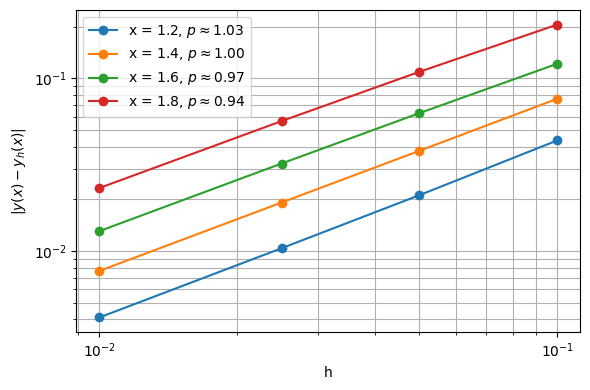

In [ ]:
plot_errors_slopes(
    method=euler_explicit,
    f=f,
    x0=x0,
    y0=y0,
    x_max=x_max,
    hs=[0.1, 0.05, 0.025, 0.01],
    x_stars=[1.2, 1.4, 1.6, 1.8],
    y_exact=y_exact
)

В случае первого порядка аппроксимации $|y-y_n|$ как функция от $h$ линейна в логарифмической шкале c наклоном, равным $p = 1$. На графике виден такой характер.

## Метод Рунге-Кутты 4го порядка

Явный $m$-этапный метод Рунге-Кутты состоит в следующем.
Предполагается, что решение $y_n = y(x_n)$ уже известно.
Задаются числовые коэффициенты
$a_i$, $b_{ij}$, $\sigma_i$
и последовательно вычисляются функции
\begin{aligned}
k_1 &= f(x_n, y_n),\\
k_2 &= f\!\left(x_n + a_2 h,\; y_n + b_{21}h k_1\right),\\
k_3 &= f\!\left(x_n + a_3 h,\; y_n + b_{31}h k_1 + b_{32}h k_2\right),\\
&\ \ \vdots\\
k_m &= f\!\left(x_n + a_m h,\;
y_n + b_{m1}h k_1 + b_{m2}h k_2 + \cdots + b_{m,m-1}h k_{m-1}\right).
\end{aligned}

Затем из формулы
$$
\frac{y_{n+1}-y_n}{h}
=
\sum_{i=1}^{m} \sigma_i k_i
$$
находится новое значение
$$
y_{n+1} = y(t_{n+1}).
$$

Необходимое требование:
$$\sum_{i=1}^{m} \sigma_i = 1.$$

Формула перехода метода Рунге–Кутты четвёртого порядка:
$$\frac{y_{n+1}-y_n}{h}
= \frac{1}{6}\,\bigl(k_1 + 2k_2 + 2k_3 + k_4\bigr),$$
где

\begin{aligned}
k&_1 = f(x_n, y_n),\\
k&_2 = f\!\left(x_n + \frac{h}{2},\, y_n + \frac{h k_1}{2}\right),\\
k&_3 = f\!\left(x_n + \frac{h}{2},\, y_n + \frac{h k_2}{2}\right),\\
k&_4 = f\!\left(x_n + h4,\, y_n + h k_3\right).
\end{aligned}


Функция ``runge_kutta_4(f, x0, y0, h, x_max)`` реализует стандартный метод Рунге-Кутты 4-го порядка, принимая на вход начало ``x0`` и конец ``x_max`` рассматриваемого отрезка, функцию ``f`` и длину шага ``h``.

In [ ]:
def runge_kutta_4(f, x0, y0, h, x_max):
    xs = [x0]
    ys = [y0]

    x = x0
    y = y0

    while x < x_max:
        k1 = f(x, y)
        k2 = f(x + h/2, y + h/2 * k1)
        k3 = f(x + h/2, y + h/2 * k2)
        k4 = f(x + h,   y + h * k3)

        y = y + h/6 * (k1 + 2*k2 + 2*k3 + k4)
        x = x + h

        xs.append(x)
        ys.append(y)

    return np.array(xs), np.array(ys)

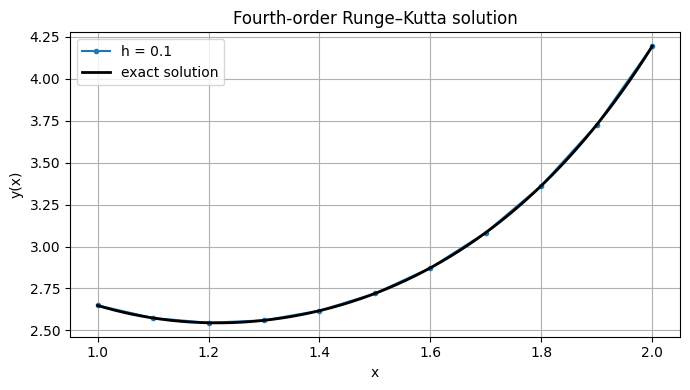

In [ ]:
plot_solution(
    method=runge_kutta_4,
    method_name="Fourth-order Runge–Kutta solution",
    f=f,
    x0=x0,
    y0=y0,
    x_max=x_max,
    hs=[0.1],
    y_exact_func=y_exact)

x = 1.2: p ≈ 4.0253
x = 1.4: p ≈ 4.0393
x = 1.6: p ≈ 4.0803
x = 1.8: p ≈ 4.3885


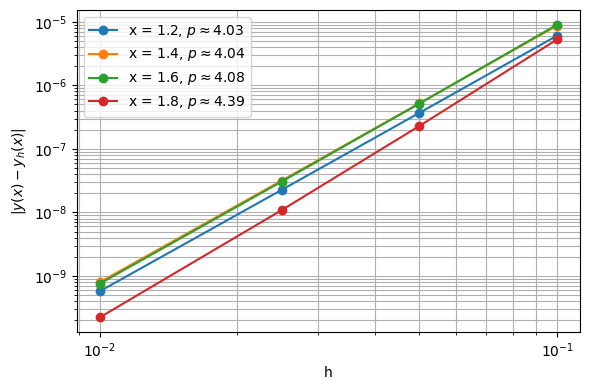

In [ ]:
plot_errors_slopes(
    method=runge_kutta_4,
    f=f,
    x0=x0,
    y0=y0,
    x_max=x_max,
    hs=[0.1, 0.05, 0.025, 0.01],
    x_stars=[1.2, 1.4, 1.6, 1.8],
    y_exact=y_exact)

Метод имеет 4-ый порядок, значит, наклон прямой $p=4$. На графике видно.

## Явный метод Адамса 4го порядка

**Многошаговые методы**

Пусть $f_n = f(x_n, y_n)$
— значения функции, определённой на сетке $x_n = x_0 + nh$.
Линейным $m$-шаговым разностным методом называется система разностных уравнений
$$
\frac{a_0 y_n + a_1 y_{n-1} + \dots + a_m y_{n-m}}{\tau}
=
b_0 f_n + b_1 f_{n-1} + \dots + b_m f_{n-m},
\qquad
n = m, m+1, \dots
$$
где $a_k$, $b_k$ — числовые коэффициенты, не зависящие от $n$,
$k = 0,1,\dots,m$ и $a_0 \neq 0$.

**Методы Адамса**

Методы Адамса представляют собой частный случай многшаговых методов,
когда производная $y'(t)$ аппроксимируется только по двум точкам
$x_n$ и $x_{n-1}$, т.е.
$$
a_0 = -a_1 = 1, \qquad
a_k = 0, \quad k = 2,3,\dots,m.
$$

Таким образом, методы Адамса имеют вид
$$
\frac{y_n - y_{n-1}}{h}
=
\sum_{k=0}^{m} b_k f_{n-k}.
$$

В случае $b_0 = 0$ методы Адамса называются явными,
в случае $b_0 \neq 0$ — неявными.

Рассматривается явный случай $m=4$. С помощью метода Рунге-Кутты находятся $y_1, y_2$ и $y_3$. Далее из рекуррентного соотношения будет выражаться $y_n$ через найденные ранее значения $y_{n-1}, y_{n-2}, y_{n-3}$ и $y_{n-4}$.

Условие 4-го порядка аппроксимации (опять из ряда Тейлора):
$$
\sum_{k=1}^{4} k^{\,l-1} b_k = \frac{1}{l}, \qquad l=1,2,3,4.
$$

Соответствующая система:

$$
\begin{cases}
b_1 + b_2 + b_3 + b_4 = 1,\\[4pt]
b_1 + 2\,b_2 + 3\,b_3 + 4\,b_4 = \dfrac12,\\[6pt]
b_1 + 2^2 b_2 + 3^2 b_3 + 4^2 b_4 = \dfrac13,\\[6pt]
b_1 + 2^3 b_2 + 3^3 b_3 + 4^3 b_4 = \dfrac14.
\end{cases}
$$

Решение системы:

$$
b_1=\frac{55}{24},\qquad
b_2=-\frac{59}{24},\qquad
b_3=\frac{37}{24},\qquad
b_4=-\frac{9}{24}.
$$

Формула для явного метода Адамса 4-го порядка:

$$
\frac{y_n - y_{n-1}}{h}
=
\frac{1}{24}
\left(
55 f_{n-1}
- 59 f_{n-2}
+ 37 f_{n-3}
- 9 f_{n-4}
\right).
$$

In [ ]:
def adams4(f, x0, y0, h, x_max):
    x_rk, y_rk = runge_kutta_4(f, x0, y0, h, x0 + 3*h)

    N = int(np.ceil((x_max - x0) / h))
    x = x0 + h * np.arange(N + 1)

    y = np.zeros((N + 1,) + np.shape(y0))
    y[:4] = y_rk[:4]

    for n in range(3, N):
        y[n+1] = y[n] + (h/24) * (55*f(x[n],   y[n]) - 59*f(x[n-1], y[n-1]) + 37*f(x[n-2], y[n-2]) - 9 *f(x[n-3], y[n-3]))

    return x, y

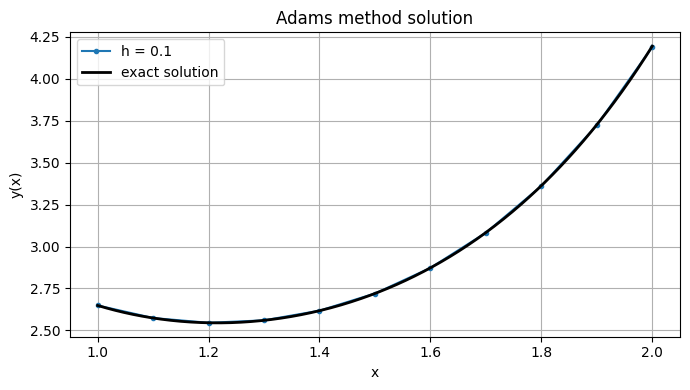

In [ ]:
plot_solution(
    method=adams4,
    method_name="Adams method solution",
    f=f,
    x0=x0,
    y0=y0,
    x_max=x_max,
    hs=[0.1],
    y_exact_func=y_exact)

x = 1.2: p ≈ 4.0253
x = 1.4: p ≈ 4.0393
x = 1.6: p ≈ 4.0803
x = 1.8: p ≈ 4.3885


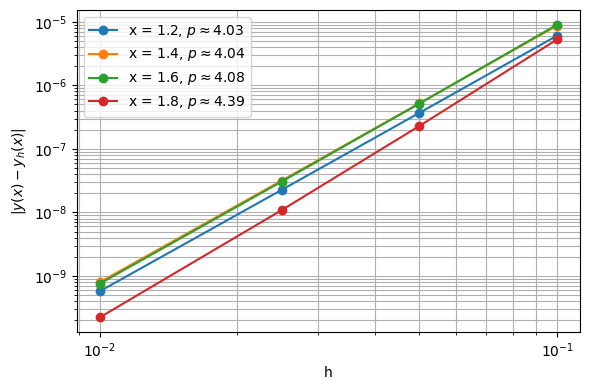

In [ ]:
plot_errors_slopes(
    method=runge_kutta_4,
    f=f,
    x0=x0,
    y0=y0,
    x_max=x_max,
    hs=[0.1, 0.05, 0.025, 0.01],
    x_stars=[1.2, 1.4, 1.6, 1.8],
    y_exact=y_exact)

Метод имеет 4-ый порядок, значит, наклон прямой $p=4$. Совпадает с результатом на графике.

#Жесткие системы

Рассматривается система дифференциальных уравнений с заданными начальными условиями:

$$
\begin{cases}
y_1' = -1000\,y_1 + 999\,y_2,\\
y_2' = -\,y_2,
\end{cases}
\qquad
y_1(0)=1,\quad y_2(0)=1,\quad t\in[0,1].
$$


Матрица системы имеет вид:

$$ A = \begin{pmatrix} -1000 & 999 \\ 0 & -1 \end{pmatrix} $$

Собственные числа этой матрицы:

$$ \lambda_1 = -1000, \quad \lambda_2 = -1 $$

Число жесткости системы определяется как отношение модулей максимального и минимального собственных чисел:

$$ S = \frac{|\lambda_1|}{|\lambda_2|} = \frac{1000}{1} = 1000 $$

**Аналитическое решение**

Решение второго уравнения:

$$ y_2' = -y_2 \implies y_2(t) = C_2 e^{-t} $$

Подстановка в первое уравнение:

$$ y_1' + 1000 y_1 = 999 C_2 e^{-t} $$

Это линейное неоднородное уравнение. Его общее решение ищется как сумма общего однородного и частного неоднородного. Получаеncя:

$$ y_1(t) = C_1 e^{-1000t} + C_2 e^{-t} $$

С учетом начальных условий, точное решение:

$$\begin{cases}
y_1(t)=e^{-t},\\
y_2(t)=e^{-t}.
\end{cases}$$

Функция ``exact_solution(t)`` представляет аналитическое решение задачи.

In [ ]:
def exact_solution(t):
    return np.exp(-t), np.exp(-t)

Функция ``system_func(t, Y)`` принимает ``t`` и вектор $(y_1, y_2)$ ``Y``,возврашает вектор производных $y_1', y_2'$.

In [ ]:
def system_func(t, Y):
    y1, y2 = Y
    dy1 = -1000 * y1 + 999 * y2
    dy2 = -y2
    return np.array([dy1, dy2])

### Неявный метод Эйлера

В неявном методе Эйлера дифференциальное уравнение
$$
y'(t) = f(t,y(t)), \qquad y(t_0)=y_0
$$
заменяется разностным уравнением
$$
\frac{y_{n+1}-y_n}{h} - f(t_{n+1}, y_{n+1}) = 0,
\qquad n = 0,1,2,\ldots, \qquad y_0 = y(t_0),
$$
то есть значение $y_{n+1}$ входит под знаком $f$ и определяется из алгебраического уравнения.

Решение уравнения ищется по рекуррентной формуле
$$
y_{n+1} = y_n + h\,f(t_{n+1}, y_{n+1}),
\qquad n = 0,1,\ldots,\qquad y_0 = y(t_0).
$$

В случае нашей жёсткой системы
$$
y'(t) = A y(t), \qquad
A = \begin{pmatrix} -1000 & 999 \\ 0 & -1 \end{pmatrix},
$$
получаем
$$
y_{n+1} = y_n + h A y_{n+1}.
$$
Переносим все слагаемые с $y_{n+1}$ в левую часть и выделяем матрицу:
$$
\bigl(I - hA\bigr)\,y_{n+1} = y_n,
$$
где $I$ — единичная матрица. Тогда на каждом шаге $y_{n+1}$ находится из системы линейных алгебраических уравнений
$$
y_{n+1} = \bigl(I - hA\bigr)^{-1} y_n.
$$
Именно эту матричную формулу реализует следующий код неявного метода Эйлера.


In [ ]:
A_stiff = np.array([[-1000.0, 999.0],
                    [    0.0,  -1.0]])


def euler_implicit_stiff(A, t0, t_end, y0, h):
    steps = int(np.round((t_end - t0) / h))
    t = np.linspace(t0, t_end, steps + 1)
    y = np.zeros((steps + 1, len(y0)))
    y[0] = y0

    I = np.eye(A.shape[0])
    M = I - h * A
    M_inv = np.linalg.inv(M)

    for n in range(steps):
        y[n+1] = M_inv @ y[n]

    return t, y

Функция ``compute_errors(methods_dict, hs, t0, t_end, y0)`` вычисляет ошибки для заданных методов.


In [ ]:
def compute_errors(methods_dict, hs, t0, t_end, y0):
    errors = {name: {'y1': [], 'y2': []} for name in methods_dict.keys()}

    for h in hs:
        for name, method_func in methods_dict.items():
            t, y = method_func(h)
            y1_exact, y2_exact = exact_solution(t)

            errors[name]['y1'].append(np.max(np.abs(y[:, 0] - y1_exact)))
            errors[name]['y2'].append(np.max(np.abs(y[:, 1] - y2_exact)))

    return errors

Функции, для упрощенного построения графиков ошибок:

In [ ]:
def plot_errors(hs, errors, title=""):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    markers = {'Explicit Euler': 'o', 'Runge–Kutta 4': 's', 'Implicit Euler': '^'}
    colors = {'Explicit Euler': 'C0', 'Runge–Kutta 4': 'C1', 'Implicit Euler': 'C2'}

    for idx, component in enumerate(['y1', 'y2']):
        ax = axes[idx]

        for name, err_dict in errors.items():
            ax.loglog(hs, err_dict[component],
                     marker=markers.get(name, 'o'),
                     color=colors.get(name, None),
                     label=name, linewidth=2)

        ax.set_xlabel("Step size h", fontsize=11)
        ax.set_ylabel(f"Max error in ${component}(t)$", fontsize=11)
        ax.set_title(f"Stability vs h ({component})", fontsize=12)
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()

    fig.suptitle(title if title else "Stability of numerical solutions vs step size",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

Функции, для упрощенного построения графиков численных решений:

In [ ]:
def plot_solutions(method_name, method_func, hs, t0, t_end, y0):

    t_exact = np.linspace(t0, t_end, 1000)
    y1_exact, y2_exact = exact_solution(t_exact)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    for h in hs:
        t, y = method_func(h)
        axes[0].plot(t, y[:, 0], marker='o', ms=3, label=f"h = {h}")
        axes[1].plot(t, y[:, 1], marker='o', ms=3, label=f"h = {h}")

    axes[0].plot(t_exact, y1_exact, 'k-', lw=2, label="exact $y_1(t)$")
    axes[1].plot(t_exact, y2_exact, 'k-', lw=2, label="exact $y_2(t)$")

    for idx, component in enumerate(['y1', 'y2']):
        axes[idx].set_xlabel("t", fontsize=11)
        axes[idx].set_ylabel(f"${component}(t)$", fontsize=11)
        axes[idx].set_title(f"{method_name}: ${component}(t)$", fontsize=12)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend()

    fig.suptitle(f"{method_name}, different step sizes h",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


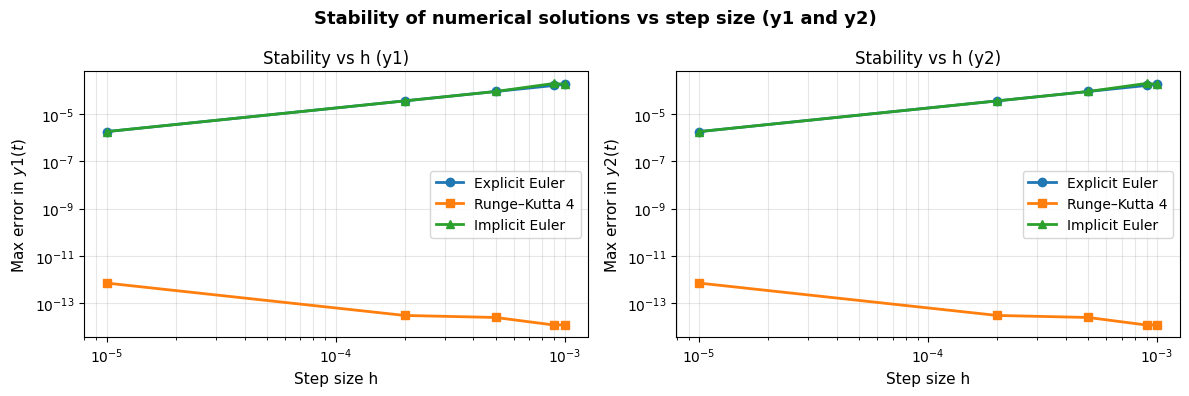

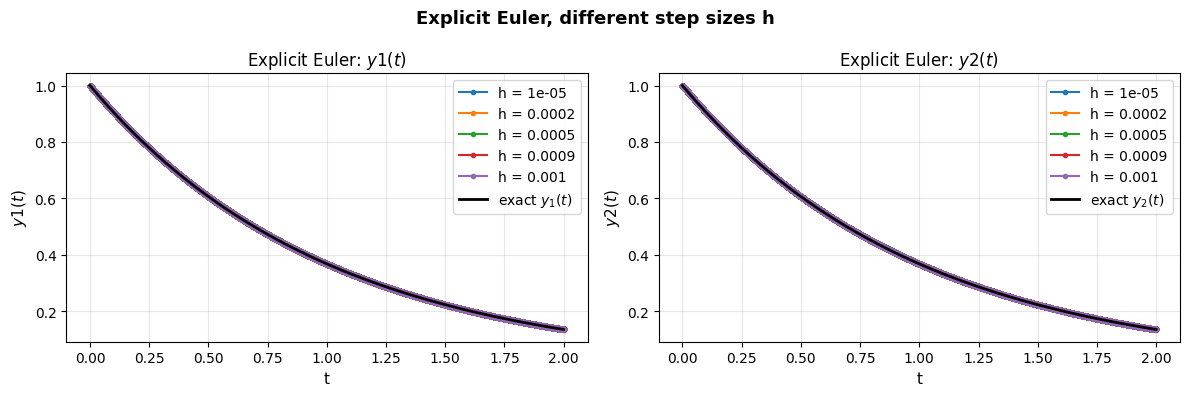

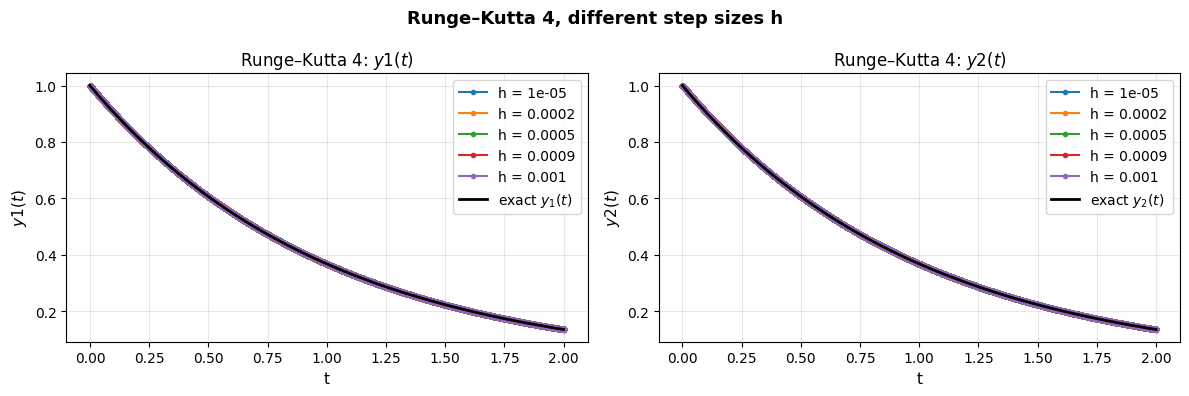

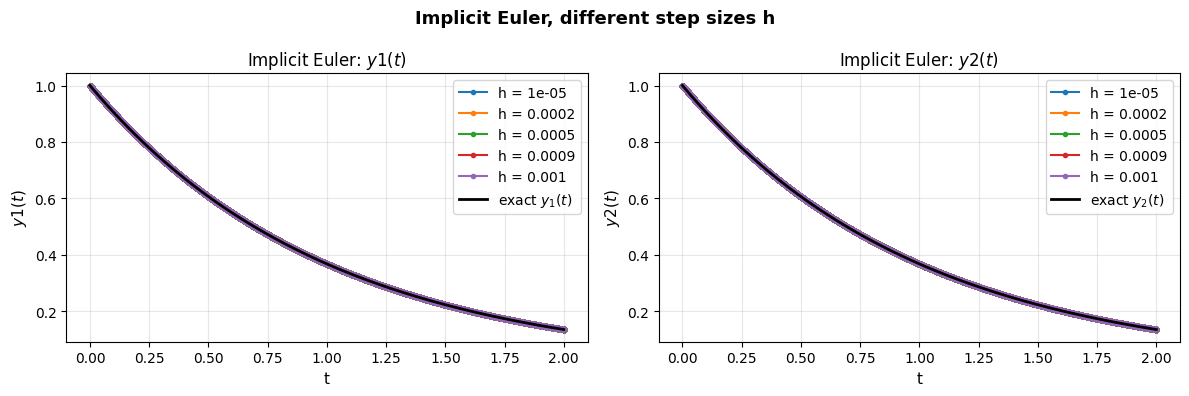

In [ ]:
t0, t_end = 0.0, 2.0
y0_stiff = np.array([1.0, 1.0])
hs = [0.00001, 0.0002, 0.0005, 0.0009, 0.001]


methods = {
    'Explicit Euler': lambda h: euler_explicit(system_func, t0, y0_stiff, h, t_end),
    'Runge–Kutta 4': lambda h: runge_kutta_4(system_func, t0, y0_stiff, h, t_end),
    'Implicit Euler': lambda h: euler_implicit_stiff(A_stiff, t0, t_end, y0_stiff, h)
}


errors = compute_errors(methods, hs, t0, t_end, y0_stiff)
plot_errors(hs, errors, "Stability of numerical solutions vs step size (y1 and y2)")


plot_solutions("Explicit Euler", methods['Explicit Euler'], hs, t0, t_end, y0_stiff)
plot_solutions("Runge–Kutta 4", methods['Runge–Kutta 4'], hs, t0, t_end, y0_stiff)
plot_solutions("Implicit Euler", methods['Implicit Euler'], hs, t0, t_end, y0_stiff)

Если взять нашу систему и применить явный метод Эйлера :
$$
y_{n+1} = y_n + h\varphi, \quad n = 0, 1, \ldots
$$

Для компоненты $y_2$ получаем: $y_{2,n+1} = y_{2,n} + h \cdot y_{2,n} = y_{2,n}(1 + h)$.
При $h = 0.01$ приращение составляет $h \cdot y_{2,n} = 0.01 \cdot y_{2,n}$ это малое изменение за шаг.

Для компоненты $y_1$: $y_{1,n+1} = y_{1,n} + h(-1000y_{1,n} + 999y_{2,n})$.
При $h = 0.01$ член $h \cdot (-1000y_{1,n}) = -10y_{1,n}$ те за один шаг $y_1$ изменяется в 10 раз по модулю это очень много

Таким образом, для $y_1$ шаг $h = 0.01$ слишком велик из-за коэффициента $-1000$, тогда как для $y_2$ тот же шаг приемлем, отсюда и получается в графиках численных решений. Чтобы увидеть совпадение обоих решений достаточно взять шаги меньше, например hs = [0.00001, 0.0002, 0.0005, 0.0009, 0.001]


Для метода Рунге-Кутты порядка $s$ локальная погрешность имеет вид:
$$
y(x_{n+1}) - y_{n+1} = \psi(x_n, y_n)h^{s+1} + O(h^{s+2})
$$
, где $\psi(x_n, y_n)$ определяется производными высокого порядка решения.

Для метода РК-4 ($s=4$) глобальная погрешность:
$$
\varepsilon_n \approx z(x_n)h^s
$$,где
$$
z(x_n) = \int_{x_0}^{x_n} \psi(\xi, y(\xi)) e^{\int_{\xi}^{x_n}\frac{\partial f}{\partial y}(\tau, y(\tau))\,d\tau}d\xi
$$

Для первой компоненты системы
$$
f_1(y_1,y_2) = -1000y_1 + 999y_2,\qquad \frac{\partial f_1}{\partial y_1} = -1000,
$$
для второй компоненты
$$
f_2(y_2) = y_2,\qquad \frac{\partial f_2}{\partial y_2} = 1.
$$

При построении функции $z(x_n)$ для компоненты $y_1$ в интеграле участвует производная
$$
\frac{\partial f_1}{\partial y_1} = -1000,
$$
видим большой по модулю коэффициент. Тем временем для второй компоненты
$$
\frac{\partial f_2}{\partial y_2} = 1
$$


Таким образом главный коэффициент погрешности $z_1(x_n)$ для $y_1$ значительно больше, чем $z_2(x_n)$ для $y_2$.

При одном и том же шаге $h = 0.01$:
$$
\varepsilon_{1,n} \cong z_1(x_n)h^{4},
$$
а для второй
$$
\varepsilon_{2,n} \cong z_2(x_n)h^{4}.
$$

Так как $z_1(x_n) \gg z_2(x_n)$ погрешность $\varepsilon_{1,n}$ оказывается на несколько порядков больше, чем $\varepsilon_{2,n}$. Поэтому численное решение для $y_1$ быстро теряет точность и взрывается, тогда как решение для $y_2$ при том же шаге остаётся устойчивым и близким к истинному.


#Метод стрельбы

Рассмотривается краевая задача

$$
\begin{cases}
y''(x) = -y(x), \\
y(0) = 0, \\
y(\pi/2) = 1.
\end{cases}
$$

Уравнение второго порядка требуется свести к системе из двух уравнений первого порядка.

Введятся новые переменные:

$$ y_1(x) = y(x) $$

$$ y_2(x) = y'(x) $$

Тогда исходное уравнение $y'' = -y$ можно переписывается как:

$$
\begin{cases}
y_1'(x) = y_2(x), \\
y_2'(x) = -y_1(x).
\end{cases}
$$


Краевые условия:

$$ y_1(0) = 0, \quad y_1(\pi/2) = 1. $$


Аналитическое решение краевой задачи

\begin{cases}
y''(x) = -y(x) \\
y(0) = 0 \\
y\left(\frac{\pi}{2}\right) = 1
\end{cases}

Это ДУ является линейным ОДУ второго порядка с постоянными коэффициентами:

$$
y'' + y = 0
$$

Тогда характеристическое уравнение:

$$
r^2 + 1 = 0 \mapsto r^2 = -1 \quad \Rightarrow \quad r_{1,2} = \pm i
$$

Jбщее решение имеет вид:

$$
y(x) = C_1 \cos(x) + C_2 \sin(x)
$$

Константы определяются из граничных условий.

В точке 0:

$$
y(0) = C_1 \cos(0) + C_2 \sin(0) = C_1 = 0 \mapsto C_1 = 0
$$

Решение принимает вид:

$$
y(x) = C_2 \sin(x)
$$

Второе условие:

$$
y\left(\frac{\pi}{2}\right) = C_2 \sin\left(\frac{\pi}{2}\right) = C_2 = 1
$$

Таким образом, аналитическое решение краевой задачи:

$$
y(x) = \sin(x)
$$

Мы ищем значение параметра:

$$
s = y'(0)
$$

Тогда

$$
s^* = y'(0) = \cos(0) = 1
$$

То есть метод Ньютона должен сходиться к значению:

$$
s^* = 1
$$



Функция `system_shoot` реализует правую часть системы:
$$
\begin{cases}
y_1'(x) = y_2(x), \\
y_2'(x) = -y_1(x).
\end{cases}
$$
Она принимает текущую координату `x` и вектор состояния `Y` (где $Y = [y_1, y_2]^T$), а возвращает вектор производных $[y_2, -y_1]^T$.


In [ ]:
def system_shoot(x, Y):
    y1, y2 = Y
    return np.array([y2, -y1])

Мы ищем такое значение параметра $s = y'(0)$, при котором функция невязки обращается в ноль:

$$ F(s) = y_1(\pi/2; s) - 1 = 0. $$



### Метод дихотомии

Выбираем начальнвые значения $s_a$ и $s_b$ так, чтобы:
$$ F(s_a) \cdot F(s_b) < 0 $$
Тогда корень $s^*$ гарантированно лежит внутри отрезка $[s_a, s_b]$.

Будем делить отрезок пополам $s_c = (s_a + s_b) / 2$ и выбирать ту половину, на концах которой знаки функции различны.

### Метод Ньютона

Итерационная формула для уравнения $F(s) = 0$:

$$ s_{k+1} = s_k - \frac{F(s_k)}{F'(s_k)} $$

Вычислим $F'(s) = \frac{\partial y_1(\pi/2; s)}{\partial s}$ и для удобства введем переменные $z_1(x)$ и $z_2(x)$:

$$ z_1(x) = \frac{\partial y_1(x; s)}{\partial s}, \quad z_2(x) = \frac{\partial y_2(x; s)}{\partial s} $$

Считая производные по параметру $s$:

$$ \frac{\partial}{\partial s} (y_1') = \frac{\partial}{\partial s} (y_2) \implies z_1' = z_2 $$

$$ \frac{\partial}{\partial s} (y_2') = \frac{\partial}{\partial s} (-y_1) \implies z_2' = -z_1 $$

И получаем начальные условия:

$$ y_1(0) = 0 \implies z_1(0) = \frac{\partial (0)}{\partial s} = 0 $$

$$ y_2(0) = s \implies z_2(0) = \frac{\partial (s)}{\partial s} = 1 $$

Получили расширенную систему из 4х уравнений:

$$
\begin{cases}
y_1' = y_2 \\
y_2' = -y_1 \\
z_1' = z_2 \\
z_2' = -z_1
\end{cases}
\quad \text{с условиями} \quad
\begin{cases}
y_1(0) = 0 \\
y_2(0) = s_k \\
z_1(0) = 0 \\
z_2(0) = 1
\end{cases}
$$

Тогда $F'(s_k) = z_1(\pi/2)$.

Функция  `residual_func(s)` принимает на вход значение параметра $s = y'(0)$, решает задачу Коши для данного $s$ и возвращает $F(s) = y_1(\pi/2; s) - 1$




In [ ]:
def residual_func(s, h=0.01):
    Y0 = np.array([0.0, s])
    xs, Ys = runge_kutta_4(system_shoot, 0.0, Y0, h, np.pi/2)
    y1_end = Ys[-1, 0]
    return y1_end - 1.0

Функция `shooting_bisection(s_a, s_b, tol)` принимает левую границу `s_a`, правую границу `s_b` и точность `tol` и возвращает найденное значение параметра $s$ методом дихотомии

In [ ]:
def shooting_bisection(s_a, s_b, tol=1e-8, h=0.01):
    fa = residual_func(s_a, h)
    fb = residual_func(s_b, h)
    if fa * fb > 0:
        raise ValueError("residual_func имеет одинаковый знак на концах отрезка")

    s_hist = []
    F_hist = []

    while (s_b - s_a) / 2 > tol:
        s_mid = 0.5 * (s_a + s_b)
        f_mid = residual_func(s_mid, h)

        s_hist.append(s_mid)
        F_hist.append(f_mid)

        if fa * f_mid < 0:
            s_b, fb = s_mid, f_mid
        else:
            s_a, fa = s_mid, f_mid

    s_star = 0.5 * (s_a + s_b)
    return s_star, np.array(s_hist), np.array(F_hist)

Функция `system_newton_extended(x, Y_ext)` реализует расширенную систему для метода Ньютона

In [ ]:
def system_newton_extended(x, Y):
    y1, y2, z1, z2 = Y
    return np.array([y2, -y1, z2, -z1])

Функция `shooting_newton(s_guess, tol)`принимает начальное приближение `s_guess` и точность `tol`возвращает найденное значение $s$ методом Ньютона

In [ ]:
def shooting_newton(s_guess, tol=1e-10, max_iter=20, h=0.01):
    s = s_guess
    s_hist = []
    F_hist = []

    for _ in range(max_iter):
        Y0_ext = np.array([0.0, s, 0.0, 1.0])
        xs, Ys = runge_kutta_4(system_newton_extended, 0.0, Y0_ext, h, np.pi/2)

        y1_end = Ys[-1, 0]
        z1_end = Ys[-1, 2]

        F_val = y1_end - 1.0
        F_deriv = z1_end

        s_hist.append(s)
        F_hist.append(F_val)

        if abs(F_val) < tol:
            break

        s = s - F_val / F_deriv

    return s, np.array(s_hist), np.array(F_hist)

4. Постройте графики итераций подбора. Сделайте выводы.

s* (bisection) = 1.0000423546880484
s* (Newton)    = 1.0000423552950395


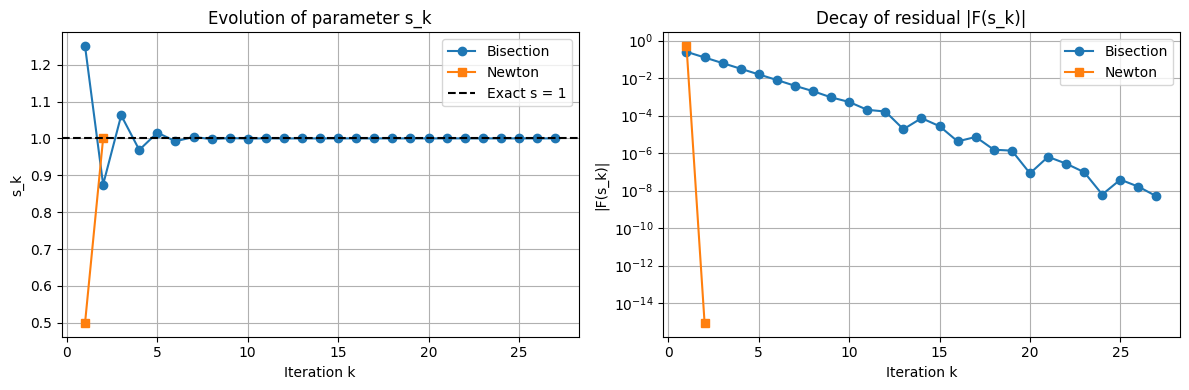

In [ ]:
s_bis, s_hist_bis, F_hist_bis = shooting_bisection(0.5, 2.0, tol=1e-8, h=0.01)
s_newt, s_hist_newt, F_hist_newt = shooting_newton(0.5, tol=1e-10, max_iter=20, h=0.01)

print("s* (bisection) =", s_bis)
print("s* (Newton)    =", s_newt)

plt.figure(figsize=(12,4))

# ---- график эволюции s_k ----
plt.subplot(1, 2, 1)
plt.plot(range(1, len(s_hist_bis) + 1), s_hist_bis, 'o-', label='Bisection')
plt.plot(range(1, len(s_hist_newt) + 1), s_hist_newt, 's-', label='Newton')
plt.axhline(1.0, color='k', linestyle='--', label='Exact s = 1')
plt.xlabel("Iteration k")
plt.ylabel("s_k")
plt.title("Evolution of parameter s_k")
plt.grid(True)
plt.legend()

# ---- график убывания |F(s_k)| ----
plt.subplot(1, 2, 2)
plt.semilogy(range(1, len(F_hist_bis) + 1), np.abs(F_hist_bis), 'o-', label='Bisection')
plt.semilogy(range(1, len(F_hist_newt) + 1), np.abs(F_hist_newt), 's-', label='Newton')
plt.xlabel("Iteration k")
plt.ylabel("|F(s_k)|")
plt.title("Decay of residual |F(s_k)|")
plt.grid(True, which="both")
plt.legend()

plt.tight_layout()
plt.show()

Из левого графика видим, что метод дихотомии медленно и монотонно сжимает значения $s_k$ к точному $s^* = 1$. Итерации метода Ньютона сходятся к тому же значению за 2 шага и уже на второй итерации $s_k$ практически совпадает с точным $s^*$.

Из правого графика видно убывание невязки $|F(s_k)|$.

Для дихотомии невязка уменьшается практически линейно по логарифмической шкале,т.е. можно говорить о медленной сходимости.

Для метода Ньютона наблюдается резкое падение невязки до машинной точности уже за две итерации, откуда мы делаем вывод, что метод имеет быструю и высокую сходимость.
